In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
file_path = '/Users/veronika/Documents/US_Accidents_Project/data/raw/US_Accidents_March23.csv'

chunks = pd.read_csv(
    file_path,
    chunksize=100000
)

In [3]:
first_chunk = next(chunks)

first_chunk.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
import os

file_size = os.path.getsize(file_path)
file_size_gb = file_size / (1024**3)

total_rows = sum(1 for line in open(file_path)) - 1

print(f"Кількість рядків raw датасету: ", total_rows)
print(f"Кількість стопців raw датасету: ", first_chunk.shape[1])
print(f"Розмір датасету: {file_size_gb:.2f} GB")

Кількість рядків raw датасету:  7728394
Кількість стопців raw датасету:  46
Розмір датасету: 2.85 GB


Оскільки даний датасет достатньо великий, роблю вибірку з frac=0.05

In [5]:
chunks = pd.read_csv(
    file_path,
    chunksize=100000
)

sample_df = pd.concat([
    chunk.sample(frac=0.05, random_state=42)
    for chunk in chunks
])

sample_df = sample_df.reset_index(drop=True)

In [6]:
print(f"Вибірка містить {sample_df.shape[0]} рядків та {sample_df.shape[1]} стовпців")

Вибірка містить 386420 рядків та 46 стовпців


In [7]:
# зберігаю вибірку у формат CSV для подальшої роботи з нею
sample_df.to_csv(
    '/Users/veronika/Documents/US_Accidents_Project/data/processed/us_accidents_sample.csv',
    index=False
)

In [8]:
# зчитую CSV з вибіркою у змінну df
df = pd.read_csv(
    '/Users/veronika/Documents/US_Accidents_Project/data/processed/us_accidents_sample.csv'
)

# Первинний огляд даних

In [9]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [10]:
df.shape

(386420, 46)

In [11]:
df.dtypes

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

In [12]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-75728,Source2,2,2016-11-28 16:23:04,2016-11-28 17:07:39,34.027828,-118.211700,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-80191,Source2,3,2016-09-28 12:33:15,2016-09-28 13:02:57,33.937790,-117.556152,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-19865,Source2,3,2016-09-13 20:16:23,2016-09-13 20:46:23,38.553600,-121.690643,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Day
3,A-76706,Source2,3,2016-09-13 10:07:38,2016-09-13 10:37:38,33.965294,-117.326668,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-92998,Source2,3,2016-08-27 17:56:49,2016-08-27 18:26:49,33.872711,-118.284805,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386420 entries, 0 to 386419
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     386420 non-null  object 
 1   Source                 386420 non-null  object 
 2   Severity               386420 non-null  int64  
 3   Start_Time             386420 non-null  object 
 4   End_Time               386420 non-null  object 
 5   Start_Lat              386420 non-null  float64
 6   Start_Lng              386420 non-null  float64
 7   End_Lat                216262 non-null  float64
 8   End_Lng                216262 non-null  float64
 9   Distance(mi)           386420 non-null  float64
 10  Description            386419 non-null  object 
 11  Street                 385893 non-null  object 
 12  City                   386406 non-null  object 
 13  County                 386420 non-null  object 
 14  State                  386420 non-nu

In [14]:
# Перевіряємо пропущені дані
df.isna().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  170158
End_Lng                  170158
Distance(mi)                  0
Description                   1
Street                      527
City                         14
County                        0
State                         0
Zipcode                      91
Country                       0
Timezone                    410
Airport_Code               1175
Weather_Timestamp          6164
Temperature(F)             8357
Wind_Chill(F)            100162
Humidity(%)                8891
Pressure(in)               7225
Visibility(mi)             9134
Wind_Direction             8971
Wind_Speed(mph)           28909
Precipitation(in)        110692
Weather_Condition          8871
Amenity                       0
Bump                          0
Crossing

Ми вже бачимо, що деякі колонки містять багато пропущених значень. Можемо працювати з ними видаляючи їх, якщо колонка не несе за собою особливою значущості для аналізу і null значень багато, або заповнити ці значення агрегаційними метриками, наприклад, середнім. На етапі очищення даних ми цим займемося.

In [15]:
# перевіряємо на дуплікати
df.duplicated().sum()

np.int64(0)

Дуплікатів в нас немає в даних, чудово!

In [16]:
# переглядаємо базові статистичні показники
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,386420.000000,386420.000000,386420.000000,216262.000000,216262.000000,386420.000000,378063.000000,286258.000000,377529.000000,379195.000000,377286.000000,357511.000000,275728.000000
mean,2.212621,36.203560,-94.744115,36.257926,-95.778068,0.555797,61.673664,58.276020,64.814070,29.539547,9.098434,7.687923,0.008073
std,0.487630,5.065599,17.411996,5.255317,18.126362,1.691876,18.965351,22.328019,22.826676,1.005566,2.709193,5.463845,0.110365
min,1.000000,24.560246,-124.535726,24.570110,-124.544508,0.000000,-89.000000,-89.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,33.420990,-117.234959,33.464445,-117.788300,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.834783,-87.764015,36.184314,-88.044809,0.030000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.070107,-80.354881,40.154374,-80.248950,0.463000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,49.000580,-67.839745,49.075000,-67.841889,149.690000,140.000000,138.000000,100.000000,38.440000,100.000000,812.000000,25.000000


In [17]:
df.select_dtypes(include='object').columns

Index(['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street',
       'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Wind_Direction',
       'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')

**Попередні висновки щодо структури та якості даних**
1. Датасет містить 386 420 рядків та 46 колонок після створення вибірки.
2. Було виявлено значну кількість пропущених значень у погодних показниках, зокрема у колонках Wind_Chill(F) та Precipitation(in).
3. Частина колонок (End_Lat, End_Lng, Airport_Code) містить велику кількість null values та має низьку аналітичну цінність для подальшого аналізу.
4. Дублікатів у вибірці не виявлено.
5. У датасеті присутня велика кількість категоріальних колонок, пов’язаних із погодними умовами, часовими характеристиками та дорожньою інфраструктурою.
6. Частина погодних показників має екстремальні значення, що може свідчити про наявність outliers або особливих погодних умов.


# Очищення та перетворення даних

In [18]:
# видалення непотрібних колонок
df.drop(columns=['Source', 'Description', 'Country', 'Zipcode', 'Airport_Code', 'End_Lat', 'End_Lng', 'Turning_Loop'], inplace=True)

In [19]:
df.shape

(386420, 38)

In [20]:
# конвертація datetime колонок
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed', errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], format='mixed', errors='coerce')

In [21]:
df[['Start_Time', 'End_Time', 'Weather_Timestamp']].dtypes

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object

In [22]:
# створюємо нові категоріальні колонки для Start_time для зручності подальшого аналізу

df['Hour'] = df['Start_Time'].dt.hour

df['Day'] = df['Start_Time'].dt.day

df['Month'] = df['Start_Time'].dt.month

df['Year'] = df['Start_Time'].dt.year

df['Weekday'] = df['Start_Time'].dt.day_name()

df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday'])

In [23]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'Street', 'City', 'County', 'State', 'Timezone',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Hour',
       'Day', 'Month', 'Year', 'Weekday', 'Is_Weekend'],
      dtype='object')

In [24]:
df[['Hour', 'Day', 'Month', 'Year', 'Weekday', 'Is_Weekend']].dtypes

Hour           int32
Day            int32
Month          int32
Year           int32
Weekday       object
Is_Weekend      bool
dtype: object

In [25]:
df[['Start_Time', 'Hour', 'Month', 'Weekday', 'Is_Weekend']].head()

,Start_Time,Hour,Month,Weekday,Is_Weekend
0,2016-11-28 16:23:04,16,11,Monday,False
1,2016-09-28 12:33:15,12,9,Wednesday,False
2,2016-09-13 20:16:23,20,9,Tuesday,False
3,2016-09-13 10:07:38,10,9,Tuesday,False
4,2016-08-27 17:56:49,17,8,Saturday,True


In [26]:
# доповнення пропущених значень погодних умов статистичним показниками
# object -> mode, float -> median

# функція для доповнення числових колонок
def fill_median(x):
    return x.fillna(x.median())

# функція для доповнення категоріальних колонок
def fill_mode(x):
    if not x.mode().empty:
        return x.fillna(x.mode()[0])
    return x.fillna('Unknown')

In [27]:
# доповнення пропущених значень погодних умов

# групуємо дані по місяцю і штату для більш точних значень
weather_group = df.groupby(['State', 'Month'])


numerical_cols = [
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)'
]

for col in numerical_cols:
    df[col] = weather_group[col].transform(fill_median)

categorical_cols = [
    'Wind_Direction',
    'Weather_Condition'
]

for col in categorical_cols:
    df[col] = weather_group[col].transform(fill_mode)

In [28]:
# додатково видаляю непотрібні колонки

df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

In [29]:
# доповнення пропущених значень інших колонок стастичними показниками

df['Timezone'] = df.groupby('State')['Timezone'].transform(fill_mode)

df['Street']  = df.groupby('City')['Street'].transform(fill_mode)

df['Sunrise_Sunset'] = df.groupby('Month')['Sunrise_Sunset'].transform(fill_mode)

In [30]:
# видаляємо колонку Weather_Timestamp, оскільки вона не несе жодної аналітичної значущості 

df = df.drop(columns=['Weather_Timestamp'])

In [31]:
# видаляємо рядки, де пропущені значення City, бо їх всього 14

df.dropna(subset=['City'], inplace=True)

In [32]:
df.shape

(386406, 40)

Бачимо, що після перетворень змінилась кількість рядків як раз на 14, а також кількість колонок. Тепер перевіримо чи залишились ще пропущені значення в датасеті:

In [33]:
df.isna().sum()

ID                   0
Severity             0
Start_Time           0
End_Time             0
Start_Lat            0
Start_Lng            0
Distance(mi)         0
Street               0
City                 0
County               0
State                0
Timezone             0
Temperature(F)       0
Wind_Chill(F)        0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Precipitation(in)    0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Sunrise_Sunset       0
Hour                 0
Day                  0
Month                0
Year                 0
Weekday              0
Is_Weekend           0
dtype: int64

Як бачимо, всі дані тепер заповнені. Перевіряємо типи даних знову:

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386406 entries, 0 to 386419
Data columns (total 40 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 386406 non-null  object        
 1   Severity           386406 non-null  int64         
 2   Start_Time         386406 non-null  datetime64[ns]
 3   End_Time           386406 non-null  datetime64[ns]
 4   Start_Lat          386406 non-null  float64       
 5   Start_Lng          386406 non-null  float64       
 6   Distance(mi)       386406 non-null  float64       
 7   Street             386406 non-null  object        
 8   City               386406 non-null  object        
 9   County             386406 non-null  object        
 10  State              386406 non-null  object        
 11  Timezone           386406 non-null  object        
 12  Temperature(F)     386406 non-null  float64       
 13  Wind_Chill(F)      386406 non-null  float64      

In [35]:
# уніфікація одиниць вимірювання даних

df['Temperature(C)'] = (df['Temperature(F)'] - 32) * 5/9

df['Wind_Chill(C)'] = (df['Wind_Chill(F)'] - 32) * 5/9

df['Distance(km)'] = df['Distance(mi)'] * 1.60934

df['Visibility(km)'] = df['Visibility(mi)'] * 1.60934

df['Wind_Speed(kmh)'] = df['Wind_Speed(mph)'] * 1.60934

df['Precipitation(mm)'] = df['Precipitation(in)'] * 25.4

df['Pressure(hPa)'] = df['Pressure(in)'] * 33.8693

In [36]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
0,A-75728,2,2016-11-28 16:23:04,2016-11-28 17:07:39,34.027828,-118.211700,0.01,US-101 N,Los Angeles,Los Angeles,...,2016,Monday,False,16.722222,14.444444,0.016093,16.0934,8.046700,0.0,1009.982526
1,A-80191,3,2016-09-28 12:33:15,2016-09-28 13:02:57,33.937790,-117.556152,0.00,6th St,Norco,Riverside,...,2016,Wednesday,False,33.277778,23.333333,0.000000,16.0934,5.632690,0.0,1013.030763
2,A-19865,3,2016-09-13 20:16:23,2016-09-13 20:46:23,38.553600,-121.690643,0.00,I-80 E,Davis,Yolo,...,2016,Tuesday,False,19.000000,23.333333,0.000000,16.0934,9.334172,0.0,1014.046842
3,A-76706,3,2016-09-13 10:07:38,2016-09-13 10:37:38,33.965294,-117.326668,0.00,I-215 S,Riverside,Riverside,...,2016,Tuesday,False,18.277778,23.333333,0.000000,16.0934,9.656040,0.0,1014.385535
4,A-92998,3,2016-08-27 17:56:49,2016-08-27 18:26:49,33.872711,-118.284805,0.00,Artesia Fwy E,Gardena,Los Angeles,...,2016,Saturday,True,22.222222,23.888889,0.000000,16.0934,14.805928,0.0,1013.708149


In [37]:
# видаляємо непотрібні колонки 

df = df.drop(columns=[
    'Temperature(F)',
    'Wind_Chill(F)',
    'Distance(mi)',
    'Visibility(mi)',
    'Precipitation(in)',
    'Pressure(in)',
    'Wind_Speed(mph)'
])

In [38]:
df.shape

(386406, 40)

In [39]:
df.describe()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Humidity(%),Hour,Day,Month,Year,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
count,386406.000000,386406,386406,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000,386406.000000
mean,2.212626,2020-06-03 23:08:42.990276864,2020-06-04 06:19:54.991516416,36.203521,-94.744579,64.828198,12.327945,15.729637,6.705294,2019.907657,16.479043,15.438185,0.894439,14.676500,12.265455,0.146330,1000.433256
min,1.000000,2016-02-08 06:15:39,2016-02-08 12:15:39,24.560246,-124.535726,1.000000,0.000000,1.000000,1.000000,2016.000000,-67.222222,-67.222222,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2018-11-22 17:26:42.750000128,2018-11-22 18:48:23.750000128,33.420853,-117.235028,49.000000,8.000000,8.000000,3.000000,2018.000000,9.444444,8.333333,0.000000,16.093400,8.046700,0.000000,995.080034
50%,2.000000,2020-11-11 06:11:41,2020-11-11 10:22:35,35.834749,-87.764664,67.000000,13.000000,16.000000,7.000000,2020.000000,17.777778,17.777778,0.048280,16.093400,11.265380,0.000000,1011.337298
75%,2.000000,2022-01-20 04:53:49.249999872,2022-01-20 16:39:42.249999872,40.070107,-80.354977,84.000000,17.000000,23.000000,10.000000,2022.000000,24.444444,23.888889,0.745124,16.093400,16.093400,0.000000,1017.095079
max,4.000000,2023-03-31 23:12:55,2023-03-31 23:42:55,49.000580,-67.839745,100.000000,23.000000,31.000000,12.000000,2023.000000,60.000000,58.888889,240.902105,160.934000,1306.784080,635.000000,1301.935892
std,0.487636,NaN,NaN,5.065618,17.412009,22.628247,5.468338,8.682515,3.640732,1.914860,10.505744,11.592850,2.722820,4.314008,8.485437,2.369815,34.176429


Після перегляду статистики по уніфікованим показниками я запідозрила викиди в деяких показниках погодних умов. Будую боксплоти, щоб підвердити, або спростувати думку.

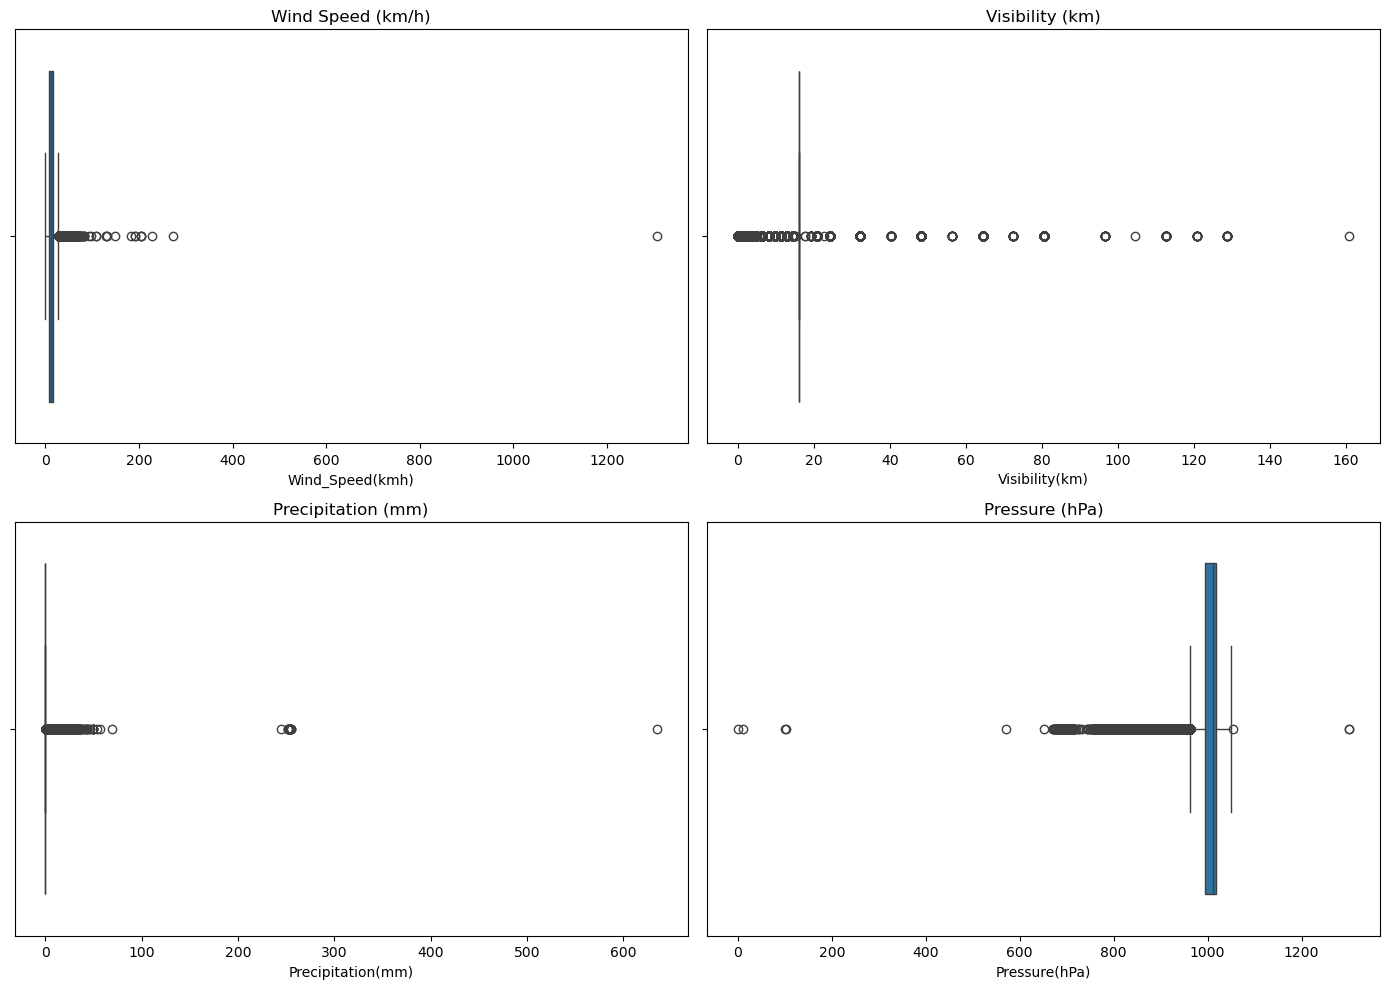

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# швидкість вітру
sns.boxplot(
    x=df['Wind_Speed(kmh)'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Wind Speed (km/h)')

# видимість
sns.boxplot(
    x=df['Visibility(km)'],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Visibility (km)')

# опади
sns.boxplot(
    x=df['Precipitation(mm)'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('Precipitation (mm)')

# тиск
sns.boxplot(
    x=df['Pressure(hPa)'],
    ax=axes[1, 1]
)
axes[1, 1].set_title('Pressure (hPa)')

plt.tight_layout()
plt.show()

Потрібно знайти дані з аномаліями, щоб переглянути і вирішити, що з ними робити

In [41]:
df[df['Wind_Speed(kmh)'] > 300]

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
285011,A-5785251,2,2021-07-12 17:44:46,2021-07-12 20:04:38,32.958287,-96.913703,I-35E N,Carrollton,Dallas,TX,...,2021,Monday,False,28.888889,28.888889,0.234964,16.0934,1306.78408,0.0,994.402648


In [42]:
df[df['Visibility(km)'] > 80]

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
41249,A-881290,2,2021-09-28 07:30:50,2021-09-28 08:00:33,39.531658,-122.249321,County Road D,Willows,Glenn,CA,...,2021,Tuesday,False,12.222222,12.222222,0.000000,160.9340,12.87472,0.0,1010.998605
49004,A-1007183,3,2021-06-12 12:30:43,2021-06-12 13:00:19,39.885254,-104.987534,I-25 N,Denver,Adams,CO,...,2021,Saturday,True,26.111111,26.111111,0.000000,104.6071,4.82802,0.0,829.459157
50786,A-1018080,3,2021-06-04 17:37:45,2021-06-04 18:07:18,39.778419,-104.907806,I-70 W,Denver,Denver,CO,...,2021,Friday,False,28.888889,28.888889,0.000000,120.7005,11.26538,0.0,825.394841
52984,A-1049129,3,2021-05-12 15:04:43,2021-05-12 16:03:21,39.839470,-104.983887,I-25 S,Denver,Adams,CO,...,2021,Wednesday,False,15.000000,15.000000,0.000000,120.7005,11.26538,0.0,831.152622
53210,A-1049114,3,2021-05-12 12:05:57,2021-05-12 13:05:34,39.759232,-105.001274,20th St,Denver,Denver,CO,...,2021,Wednesday,False,12.222222,12.222222,0.000000,120.7005,8.04670,0.0,832.507394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384197,A-7706077,2,2019-04-09 15:10:56,2019-04-09 15:38:55,39.721760,-105.008980,US-87 N,Denver,Denver,CO,...,2019,Tuesday,False,23.888889,23.888889,1.073430,80.4670,9.65604,0.0,816.588823
384304,A-7711750,4,2019-04-19 07:08:54,2019-04-19 09:08:23,39.778280,-104.896660,I-270 E,Denver,Denver,CO,...,2019,Friday,False,7.222222,5.555556,0.482802,96.5604,8.04670,0.0,829.797850
385695,A-7772306,3,2019-08-12 18:39:33,2019-08-12 19:08:51,39.657549,-105.224183,Highway 74,Morrison,Jefferson,CO,...,2019,Monday,False,28.888889,28.888889,2.396307,80.4670,4.82802,0.0,828.443078
385851,A-7760571,3,2019-07-18 09:40:29,2019-07-18 10:10:07,39.784320,-105.115090,I-70 W,Wheat Ridge,Jefferson,CO,...,2019,Thursday,False,27.222222,27.222222,0.955948,112.6538,4.82802,0.0,826.749613


In [43]:
df[
    (df['Pressure(hPa)'] < 850) |
    (df['Pressure(hPa)'] > 1100)
]

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
5281,A-159005,2,2016-07-11 18:34:28,2016-07-11 19:04:28,34.004322,-84.577278,Ernest W Barrett Pkwy NW,Kennesaw,Cobb,GA,...,2016,Monday,False,23.000000,26.666667,0.000000,11.26538,7.402964,0.0,101.607900
7054,A-110373,2,2016-05-29 05:23:35,2016-05-29 05:53:35,33.971817,-117.846436,CA-57 S,Diamond Bar,Los Angeles,CA,...,2016,Sunday,True,14.000000,18.888889,0.016093,8.04670,7.402964,0.0,778.993900
25071,A-532671,2,2022-08-19 07:46:29,2022-08-19 08:37:52,39.564629,-105.031387,CO-470 W,Littleton,Douglas,CO,...,2022,Friday,False,17.222222,17.222222,1.689807,16.09340,8.046700,0.0,822.007911
25113,A-558514,1,2022-07-22 07:11:44,2022-07-22 07:40:48,38.843552,-104.856697,W Colorado Ave,Colorado Springs,El Paso,CO,...,2022,Friday,False,18.333333,18.333333,0.000000,16.09340,14.484060,0.0,802.363717
25116,A-569546,3,2022-07-11 14:04:53,2022-07-11 15:22:05,39.175671,-120.857430,I-80,Dutch Flat,Placer,CA,...,2022,Monday,False,28.333333,28.333333,0.000000,16.09340,11.265380,0.0,841.990798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386207,A-7767977,2,2019-08-02 19:41:00,2019-08-02 23:59:00,37.593267,-112.885876,Cedar Cyn,Cedar City,Iron,UT,...,2019,Friday,False,30.000000,30.000000,0.123919,16.09340,19.312080,0.0,830.136543
386227,A-7757408,2,2019-07-11 09:29:00,2019-07-11 10:30:00,40.198610,-110.890284,US-40 E,Mountain Home,Duchesne,UT,...,2019,Thursday,False,25.000000,25.000000,0.046671,16.09340,8.046700,0.0,844.361649
386335,A-7772289,3,2019-08-12 18:25:23,2019-08-12 18:54:36,39.838478,-104.983520,I-25 N,Denver,Adams,CO,...,2019,Monday,False,28.888889,28.888889,0.497286,80.46700,4.828020,0.0,828.443078
386358,A-7770938,4,2019-08-09 11:48:43,2019-08-09 12:15:41,39.308813,-106.245306,Highway 91,Leadville,Lake,CO,...,2019,Friday,False,17.777778,17.777778,5.471756,16.09340,8.046700,0.0,711.593993


In [44]:
df[df['Precipitation(mm)'] > 250]

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
8535,A-194772,2,2016-12-05 04:54:47,2016-12-05 05:24:36,40.695984,-73.983955,Tillary St,Brooklyn,Kings,NY,...,2016,Monday,False,4.000000,0.888889,0.016093,16.093400,13.035654,254.508,1030.304106
9375,A-195720,3,2016-12-09 20:27:25,2016-12-09 21:12:11,40.691647,-73.999306,Brooklyn Queens Expy,Brooklyn,Kings,NY,...,2016,Friday,False,1.000000,-0.666667,0.016093,16.093400,5.632690,252.222,1030.642799
10671,A-206155,2,2016-11-18 19:52:56,2016-11-18 20:37:41,40.606880,-73.947945,Avenue R,Brooklyn,Kings,NY,...,2016,Friday,False,13.000000,3.333333,0.000000,12.874720,12.874720,253.238,1030.304106
11940,A-205718,2,2016-11-16 16:16:38,2016-11-16 17:01:23,40.588562,-73.983711,Stillwell Ave,Brooklyn,Kings,NY,...,2016,Wednesday,False,16.000000,3.333333,0.016093,16.093400,20.438618,252.222,1029.965413
17992,A-327963,3,2017-02-09 07:55:01,2017-02-09 08:24:46,40.642128,-74.020569,60th St,Brooklyn,Kings,NY,...,2017,Thursday,False,0.000000,-2.500000,0.016093,0.321868,7.402964,253.492,1029.965413
94694,A-1879782,2,2019-09-25 05:59:53,2019-09-25 07:30:31,35.005810,-89.864388,E Holmes Rd,Memphis,Shelby,TN,...,2019,Wednesday,False,21.111111,21.111111,0.000000,16.093400,4.828020,635.000,998.128271
129135,A-2581227,3,2018-09-13 04:12:58,2018-09-13 04:42:28,40.710907,-73.955963,Brooklyn Queens Expy,Brooklyn,Kings,NY,...,2018,Thursday,False,22.000000,20.555556,0.000000,16.093400,12.874720,251.968,1030.642799
143218,A-2829375,3,2018-05-17 08:13:20,2018-05-17 08:42:54,40.667114,-73.995918,Gowanus Expy E,Brooklyn,Kings,NY,...,2018,Thursday,False,14.000000,16.666667,0.000000,14.484060,11.104446,252.984,1030.304106
145046,A-2961564,2,2018-03-22 11:48:17,2018-03-22 12:17:56,40.732208,-74.044380,14th St,Jersey City,Hudson,NJ,...,2018,Thursday,False,7.000000,5.222222,0.000000,16.093400,9.334172,253.238,1016.417693
157673,A-3181370,3,2017-11-13 11:13:53,2017-11-13 11:43:21,40.724510,-74.007027,Broome St,New York,New York,NY,...,2017,Monday,False,8.000000,4.833333,4.168190,16.093400,20.438618,253.746,1013.030763


In [45]:
# перевіряю також Distance

df[
    df['Distance(km)'] > 100
]

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Street,City,County,State,...,Year,Weekday,Is_Weekend,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
30659,A-679525,3,2022-03-12 08:58:54,2022-03-12 09:27:38,34.024303,-79.992981,Lynches River Rd,Lynchburg,Sumter,SC,...,2022,Saturday,True,16.111111,16.111111,122.712175,16.093400,20.92142,0.000,992.370490
36567,A-732670,2,2022-01-27 10:29:01,2022-01-27 10:57:42,28.260864,-81.331642,Mickey Johnson Ct,Kissimmee,Osceola,FL,...,2022,Thursday,False,17.777778,17.777778,126.928650,16.093400,20.92142,0.000,1018.788544
37163,A-714796,4,2022-02-10 07:08:08,2022-02-10 07:36:54,44.803169,-117.813187,I-84 W,Baker City,Baker,OR,...,2022,Thursday,False,-8.888889,-8.888889,185.685645,0.402335,0.00000,0.000,911.084170
37986,A-782792,2,2021-12-12 07:04:13,2021-12-12 07:33:18,27.699244,-80.896408,Florida's Tpke S,Okeechobee,Osceola,FL,...,2021,Sunday,True,17.222222,17.222222,104.526628,0.402335,0.00000,0.000,1019.804623
48401,A-988904,3,2021-06-26 09:24:49,2021-06-26 11:08:55,40.216022,-76.073502,I-76 W,Denver,Lancaster,PA,...,2021,Saturday,True,25.000000,25.000000,100.986085,16.093400,12.87472,0.000,1008.966447
60553,A-1246619,2,2020-11-30 09:48:06,2020-11-30 11:03:32,28.222511,-81.318359,Florida's Tpke N,Saint Cloud,Osceola,FL,...,2020,Monday,False,19.444444,19.444444,119.252092,6.437360,20.92142,0.000,1010.321219
66230,A-1368323,2,2020-08-31 10:51:28,2020-08-31 11:21:01,32.792549,-107.920181,Highway 152,Hanover,Grant,NM,...,2020,Monday,False,26.111111,26.111111,173.535135,16.093400,35.40548,0.000,833.862166
77212,A-1543629,3,2020-04-01 19:35:16,2020-04-01 23:04:19,27.699369,-80.896622,State Road 60,South and East Osceola,Osceola,FL,...,2020,Wednesday,False,22.222222,22.222222,119.718802,16.093400,4.82802,0.000,1009.643833
110946,A-2277577,2,2019-02-11 09:44:06,2019-02-11 10:13:12,29.681070,-97.169128,W US Highway 90,Flatonia,Fayette,TX,...,2019,Monday,False,13.277778,6.666667,122.309840,0.804670,14.48406,0.000,1013.708149
159176,A-3164400,3,2017-11-02 04:13:37,2017-11-02 05:57:38,40.723682,-116.018166,Chestnut St,Carlin,Elko,NV,...,2017,Thursday,False,-1.111111,1.111111,117.884155,16.093400,8.04670,0.000,1010.321219


Висновки по outliers
1. Wind Speed - один явний викід, видаляємо.
2. Visibility - 187 дуже високих значень. Видалення цих рядків для датасету 380К+ рядків не критично.
3. Precipitation - 22 рядки, також можна очистити.
4. Pressure - 5279 рядків. Швидкий варіант - видалити, а можна замінити аномальні значення медіанами.
5. Distance - 17 рядків, можна спокійно видалити.

In [46]:
# замінюємо outliers значеннями медіани тиску через фільтрацію

pressure_med = df['Pressure(hPa)'].median()

df.loc[
    (
        (df['Pressure(hPa)'] < 850) |
        (df['Pressure(hPa)'] > 1100)
    ),
    'Pressure(hPa)'
] = pressure_med

In [47]:
# Видаляємо рядки з викидами Температури, швидкості вітру та опадів

df = df[df['Wind_Speed(kmh)'] <= 300]
df = df[df['Visibility(km)'] <= 80]
df = df[df['Precipitation(mm)'] <= 250]
df = df[df['Distance(km)'] <= 100]

In [48]:
df.shape

(386179, 40)

In [49]:
df.describe()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Humidity(%),Hour,Day,Month,Year,Temperature(C),Wind_Chill(C),Distance(km),Visibility(km),Wind_Speed(kmh),Precipitation(mm),Pressure(hPa)
count,386179.000000,386179,386179,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000,386179.000000
mean,2.212451,2020-06-04 05:43:58.602596096,2020-06-04 12:55:22.429732864,36.201762,-94.739564,64.842846,12.328397,15.730242,6.705372,2019.908400,16.480405,15.441330,0.888751,14.638714,12.261750,0.130986,1003.119348
min,1.000000,2016-02-08 06:15:39,2016-02-08 12:15:39,24.560246,-124.535726,1.000000,0.000000,1.000000,1.000000,2016.000000,-67.222222,-67.222222,0.000000,0.000000,0.000000,0.000000,850.119430
25%,2.000000,2018-11-23 08:30:25.500000,2018-11-23 09:48:19.500000,33.418971,-117.236343,49.000000,8.000000,8.000000,3.000000,2018.000000,9.444444,8.333333,0.000000,16.093400,8.046700,0.000000,996.096113
50%,2.000000,2020-11-11 11:31:00,2020-11-11 18:46:30,35.832581,-87.755623,67.000000,13.000000,16.000000,7.000000,2020.000000,17.777778,17.777778,0.048280,16.093400,11.265380,0.000000,1011.337298
75%,2.000000,2022-01-20 07:41:03.500000,2022-01-20 18:13:06.500000,40.070550,-80.354266,84.000000,17.000000,23.000000,10.000000,2022.000000,24.444444,23.888889,0.745124,16.093400,16.093400,0.000000,1017.095079
max,4.000000,2023-03-31 23:12:55,2023-03-31 23:42:55,49.000580,-67.839745,100.000000,23.000000,31.000000,12.000000,2023.000000,60.000000,58.888889,97.921902,72.420300,271.978460,245.110000,1054.690002
std,0.487506,NaN,NaN,5.066201,17.413618,22.619923,5.468872,8.682609,3.640670,1.914799,10.505465,11.591824,2.562403,3.935780,8.225662,1.043121,25.800936


На цьому етапі дані були очищені від основних аномалій та викидів. Після очищення у колонці атмосферного тиску все ще спостерігається відносно велике стандартне відхилення, що можна пояснити різними погодними умовами, штатами та сезонами, представленими у датасеті.

Датасет було очищено, оброблено пропущені значення, усунуто основні аномалії та виконано перетворення колонок. Після завершення даного етапу очищений датасет можна зберегти для подальшого аналізу, статистичних досліджень та створення візуалізацій.

In [50]:
df.to_csv(
    '/Users/veronika/Documents/US_Accidents_Project/data/processed/cleaned_us_accidents.csv',
    index=False
)